# 06 - SHAP Explainability Analysis
Member 3 (Explainability & Narrative Engineer)
---

## Purpose

Explain the predictions of the trained models using SHAP (SHapley Additive exPlanations).  SHAP tells us **why** the model made each prediction, by scoring how much each feature pushed the prediction toward or away from each class.

This notebook produces:

1. **Global explanations** - which features matter most across all companies (per class)
2. **Local explanations** - waterfall plots for individual company predictions
3. **Case studies** - correctly and incorrectly classified companies from the test set
4. **SHAP arrays saved to disk** - input for the LLM narrative notebook (07)

## Model Choice

We use **XGBoost** as the primary model for SHAP because:
- It is our best-performing model (F1-macro = 0.847)
- **TreeSHAP is exact and fast** for tree models (no sampling approximation)
- Its explanations are directly comparable to the model comparison in notebook 05

We also run SHAP on the logistic baseline (for a linear-model contrast) and note that neural-model SHAP (MLP, TabTransformer) would use DeepSHAP with a background sample - included for the paper but slower.

## Step 1 - Setup

In [15]:
import os, sys, json
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from predict import explain_ready, load_model, feature_columns, class_names
import config as C

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi']  = 110
plt.rcParams['savefig.dpi'] = 200

# Output folders
SHAP_DIR = C.RESULTS_DIR / 'shap'
PLOTS_DIR = C.FIGURES_DIR / 'shap'
SHAP_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('SHAP version:', shap.__version__)
print('Classes:     ', class_names())
print('Features:    ', len(feature_columns()))
print('Outputs to:  ', SHAP_DIR)

SHAP version: 0.52.0
Classes:      ['At-Risk', 'Distressed', 'Healthy']
Features:     23
Outputs to:   D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\shap


## Step 2 - Load the Best Model and the Test Set

In [16]:
pkg = explain_ready('xgboost')

model         = pkg['model']
X             = pkg['X']                # (n_rows, n_features) DataFrame
raw           = pkg['raw']              # original rows for readable case studies
y_true_lbl    = pkg['y_true_labels']    # string labels
y_pred_lbl    = pkg['y_pred_labels']    # string labels
proba         = pkg['proba']            # (n_rows, 3)
classes       = pkg['class_names']      # ['At-Risk', 'Distressed', 'Healthy']
feature_cols  = pkg['feature_columns']

print(f'Test set:       {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Classes:        {classes}')
print(f'Correct pred:   {(y_true_lbl == y_pred_lbl).sum():,} / {len(y_true_lbl):,}  '
      f'({(y_true_lbl == y_pred_lbl).mean()*100:.1f}%)')

Test set:       1,379 rows x 23 features
Classes:        ['At-Risk', 'Distressed', 'Healthy']
Correct pred:   1,184 / 1,379  (85.9%)


## Step 3 - Compute TreeSHAP Values for XGBoost

In [17]:
explainer   = shap.TreeExplainer(model)
shap_values = np.asarray(explainer.shap_values(X))

# Recent SHAP versions can return (rows, features) for the last class only in some
# XGBoost setups. Normalise to (rows, features, classes) so downstream code always works.
if shap_values.ndim == 2:
    raise RuntimeError('Expected 3D SHAP output for multi-class. Re-check model type.')

print(f'SHAP array shape: {shap_values.shape}   (rows, features, classes)')
print(f'Expected values:  {explainer.expected_value}')

SHAP array shape: (1379, 23, 3)   (rows, features, classes)
Expected values:  [np.float32(0.10636442), np.float32(-0.071949385), np.float32(-0.06455642)]


## Step 4 - Global Explanation: Mean Absolute SHAP per Feature

In [18]:
# mean(|SHAP|) shape: (n_features, n_classes)
mean_abs = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame(mean_abs, index=feature_cols, columns=classes)

# Overall importance (mean across classes)
importance_df['Overall'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Overall', ascending=False)

print('Top 10 features by mean |SHAP|:')
importance_df.head(10).round(4)

Top 10 features by mean |SHAP|:


,At-Risk,Distressed,Healthy,Overall
asset_turnover,0.3337,1.0296,1.2906,0.8846
debt_to_equity,0.3127,0.6561,1.1115,0.6934
ebit_margin,0.1675,0.6620,0.5569,0.4621
net_margin,0.2294,0.4100,0.3070,0.3155
current_ratio,0.0754,0.2799,0.3378,0.2310
opex_ratio,0.0850,0.1861,0.1230,0.1313
revenue_growth,0.0428,0.1198,0.1187,0.0938
size_bucket_micro,0.0757,0.1713,0.0333,0.0934
leverage_tier_low,0.0288,0.0842,0.1331,0.0820
leverage_tier_high,0.0094,0.1100,0.0841,0.0678


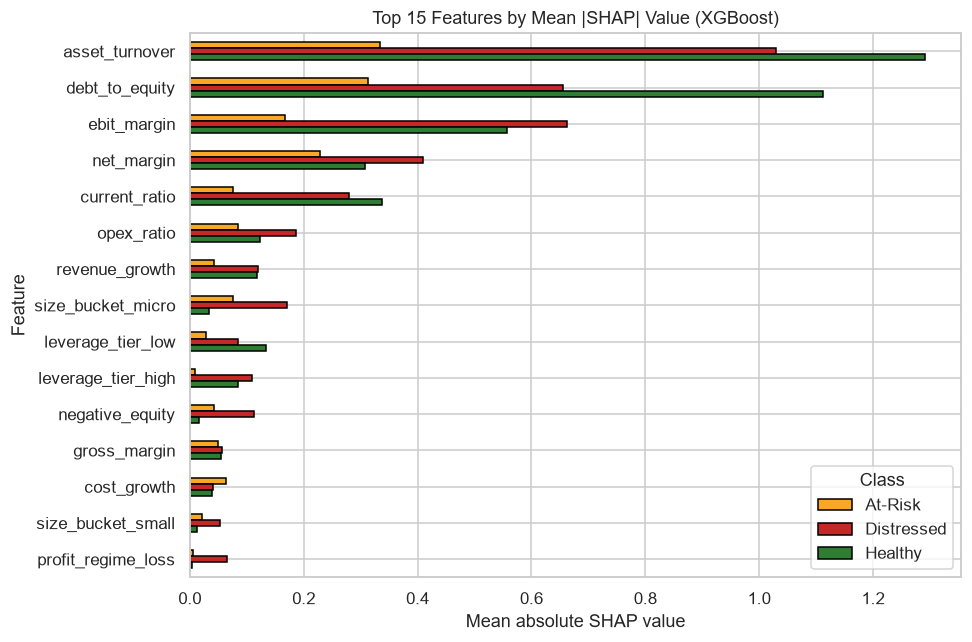

In [19]:
# Bar plot - overall
fig, ax = plt.subplots(figsize=(9, 6))

top15 = importance_df.head(15)[classes]
top15.plot(kind='barh', stacked=False, ax=ax, edgecolor='black',
           color=['#F9A825', '#C62828', '#2E7D32'])

ax.set_title('Top 15 Features by Mean |SHAP| Value (XGBoost)')
ax.set_xlabel('Mean absolute SHAP value')
ax.set_ylabel('Feature')
ax.invert_yaxis()
ax.legend(title='Class', loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_mean_abs_shap_top15.png', bbox_inches='tight')
plt.show()

## Step 5 - Beeswarm Plots per Class

--- Beeswarm for class: At-Risk ---


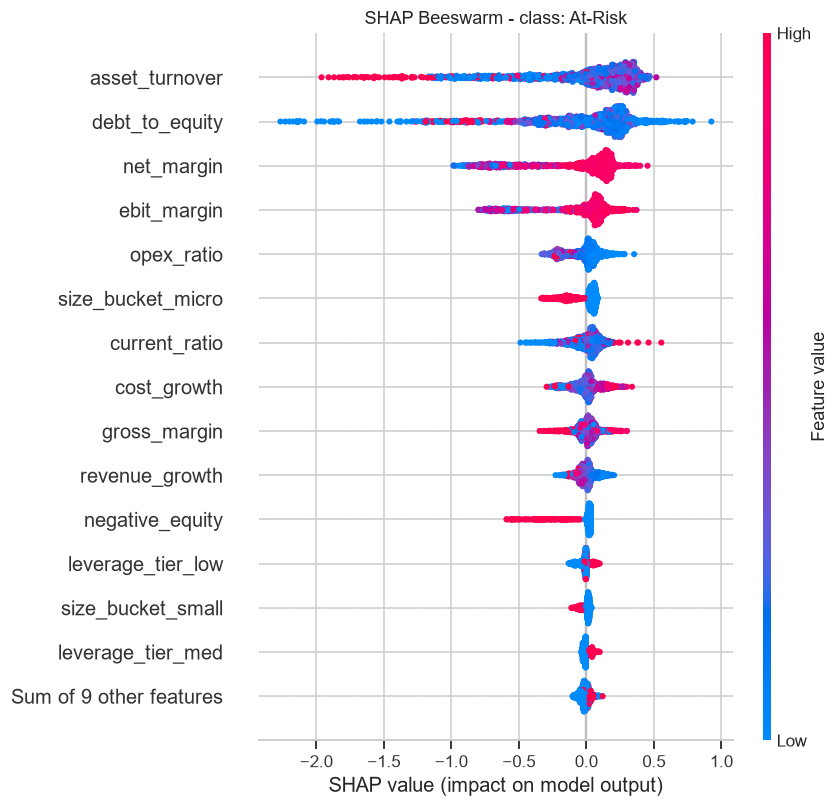

--- Beeswarm for class: Distressed ---


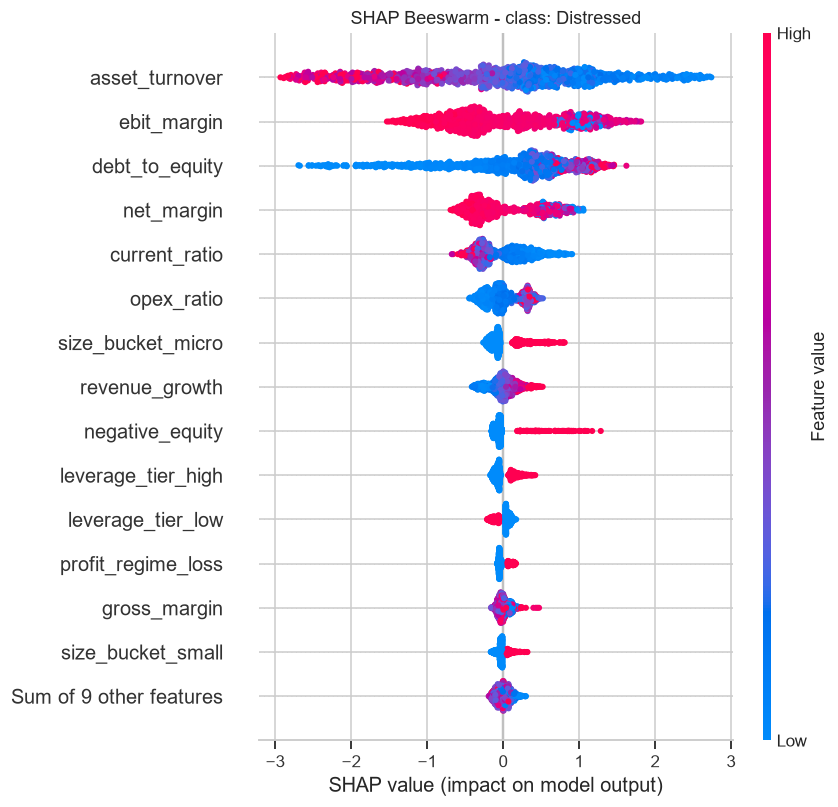

--- Beeswarm for class: Healthy ---


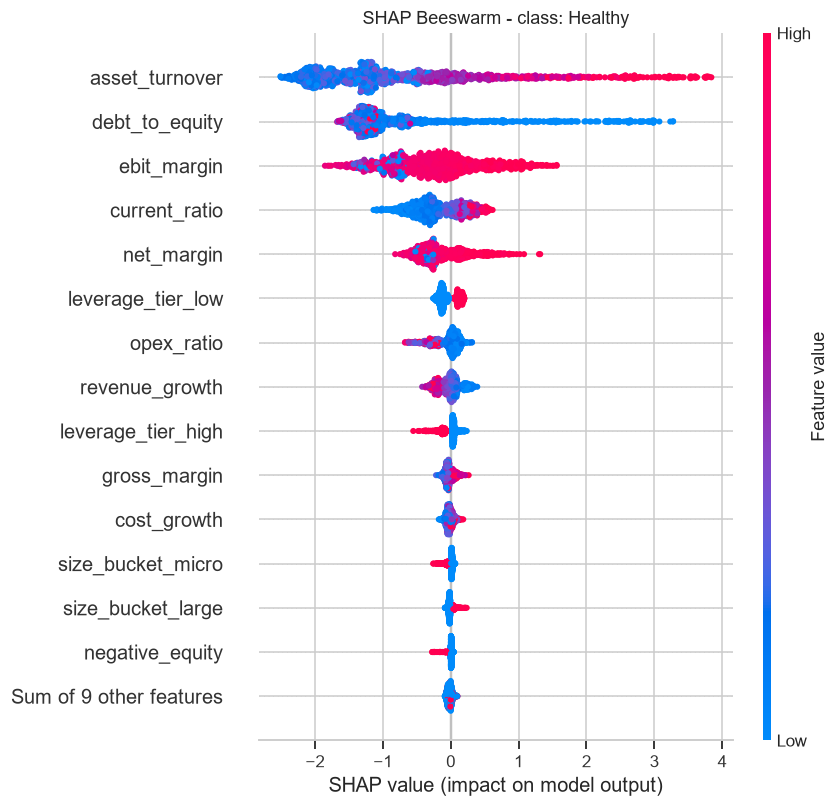

In [20]:
for cls_idx, cls_name in enumerate(classes):
    print(f'--- Beeswarm for class: {cls_name} ---')

    # Build a shap.Explanation for one class
    exp = shap.Explanation(
        values      = shap_values[:, :, cls_idx],
        base_values = np.full(X.shape[0], explainer.expected_value[cls_idx]),
        data        = X.values,
        feature_names = feature_cols,
    )

    fig = plt.figure()
    shap.plots.beeswarm(exp, max_display=15, show=False)
    plt.title(f'SHAP Beeswarm - class: {cls_name}')
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / f'02_beeswarm_{cls_name.lower().replace("-", "_")}.png',
                bbox_inches='tight')
    plt.show()

## Step 6 - Save SHAP Values for the LLM Notebook

In [21]:
# 1) raw arrays
np.save(SHAP_DIR / 'shap_values_xgboost.npy', shap_values)
np.save(SHAP_DIR / 'expected_values_xgboost.npy', np.asarray(explainer.expected_value))
print(f'Saved: {SHAP_DIR}/shap_values_xgboost.npy       {shap_values.shape}')
print(f'Saved: {SHAP_DIR}/expected_values_xgboost.npy   ({len(explainer.expected_value)},)')

Saved: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\shap/shap_values_xgboost.npy       (1379, 23, 3)
Saved: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\shap/expected_values_xgboost.npy   (3,)


In [22]:
# 2) tidy table - one row per company-year with the top-3 features that
#    drove the predicted class
def top_features_for_row(row_idx, k=3):
    pred_cls = int(np.argmax(proba[row_idx]))
    contributions = shap_values[row_idx, :, pred_cls]     # (n_features,)
    # sort by absolute contribution
    order = np.argsort(-np.abs(contributions))[:k]
    return [(feature_cols[i], float(contributions[i]), float(X.iloc[row_idx, i])) for i in order]

rows = []
for i in range(len(X)):
    top = top_features_for_row(i, k=3)
    row_info = {
        'company_id':       raw.iloc[i].get('company_id', ''),
        'year':             int(raw.iloc[i].get('year', 0)) if 'year' in raw.columns else None,
        'true_label':       y_true_lbl[i],
        'predicted_label':  y_pred_lbl[i],
        'proba_at_risk':    float(proba[i, classes.index('At-Risk')]),
        'proba_distressed': float(proba[i, classes.index('Distressed')]),
        'proba_healthy':    float(proba[i, classes.index('Healthy')]),
        'correct':          bool(y_true_lbl[i] == y_pred_lbl[i]),
    }
    for j, (fname, sv, fv) in enumerate(top, 1):
        row_info[f'top{j}_feature']   = fname
        row_info[f'top{j}_shap']      = round(sv, 4)
        row_info[f'top{j}_value']     = round(fv, 4)
    rows.append(row_info)

shap_summary = pd.DataFrame(rows)
shap_summary.to_csv(SHAP_DIR / 'shap_top_features_xgboost.csv', index=False)
print(f'Saved: {SHAP_DIR}/shap_top_features_xgboost.csv  ({len(shap_summary):,} rows)')

shap_summary.head(5)

Saved: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\shap/shap_top_features_xgboost.csv  (1,379 rows)


,company_id,year,true_label,predicted_label,proba_at_risk,proba_distressed,proba_healthy,correct,top1_feature,top1_shap,top1_value,top2_feature,top2_shap,top2_value,top3_feature,top3_shap,top3_value
0,A21,2021,At-Risk,At-Risk,0.495591,0.469098,0.035310,True,asset_turnover,-0.3272,0.0677,debt_to_equity,0.2552,0.5061,cost_growth,-0.1772,-0.4636
1,AAL,2021,Distressed,Distressed,0.011667,0.988016,0.000317,True,ebit_margin,0.8568,-0.1695,debt_to_equity,0.7704,1.1519,net_margin,0.5299,-0.0667
2,AAL,2022,Distressed,Distressed,0.121042,0.877241,0.001717,True,negative_equity,0.6012,1.0000,debt_to_equity,0.5640,1.1519,ebit_margin,0.4229,0.0328
3,AAL,2023,Distressed,Distressed,0.262448,0.734750,0.002803,True,negative_equity,0.9006,1.0000,current_ratio,0.4317,0.6152,debt_to_equity,0.3944,1.1519
4,AAL,2024,Distressed,Distressed,0.294915,0.701904,0.003180,True,negative_equity,0.9017,1.0000,current_ratio,0.4908,0.5414,debt_to_equity,0.3799,1.1519


## Step 7 - Local Case Studies

In [23]:
def pick_case(condition_fn, description):
    """Return the first test-set row index matching a condition."""
    idx = np.where([condition_fn(i) for i in range(len(X))])[0]
    if len(idx) == 0:
        print(f'No row matches: {description}')
        return None
    return int(idx[0])

cases = {
    'Correctly classified Distressed (high confidence)':
        pick_case(lambda i: y_pred_lbl[i]=='Distressed' and y_true_lbl[i]=='Distressed' and proba[i, classes.index('Distressed')] > 0.9,
                  'confident correct distressed'),
    'Correctly classified Healthy (high confidence)':
        pick_case(lambda i: y_pred_lbl[i]=='Healthy' and y_true_lbl[i]=='Healthy' and proba[i, classes.index('Healthy')] > 0.9,
                  'confident correct healthy'),
    'Confidently wrong':
        pick_case(lambda i: y_pred_lbl[i]!=y_true_lbl[i] and proba[i].max() > 0.85,
                  'confident wrong'),
    'Ambiguous (close probabilities)':
        pick_case(lambda i: sorted(proba[i])[-1] - sorted(proba[i])[-2] < 0.10,
                  'ambiguous prediction'),
}

for label, idx in cases.items():
    if idx is None:
        continue
    print(f'{label:55s}  row {idx:5d}  '
          f'true={y_true_lbl[idx]:10s}  pred={y_pred_lbl[idx]:10s}  '
          f'proba={dict(zip(classes, proba[idx].round(2)))}')

Correctly classified Distressed (high confidence)        row     1  true=Distressed  pred=Distressed  proba={'At-Risk': np.float32(0.01), 'Distressed': np.float32(0.99), 'Healthy': np.float32(0.0)}
Correctly classified Healthy (high confidence)           row     7  true=Healthy     pred=Healthy     proba={'At-Risk': np.float32(0.03), 'Distressed': np.float32(0.02), 'Healthy': np.float32(0.95)}
Confidently wrong                                        row    89  true=Distressed  pred=At-Risk     proba={'At-Risk': np.float32(0.9), 'Distressed': np.float32(0.08), 'Healthy': np.float32(0.02)}
Ambiguous (close probabilities)                          row     0  true=At-Risk     pred=At-Risk     proba={'At-Risk': np.float32(0.5), 'Distressed': np.float32(0.47), 'Healthy': np.float32(0.04)}


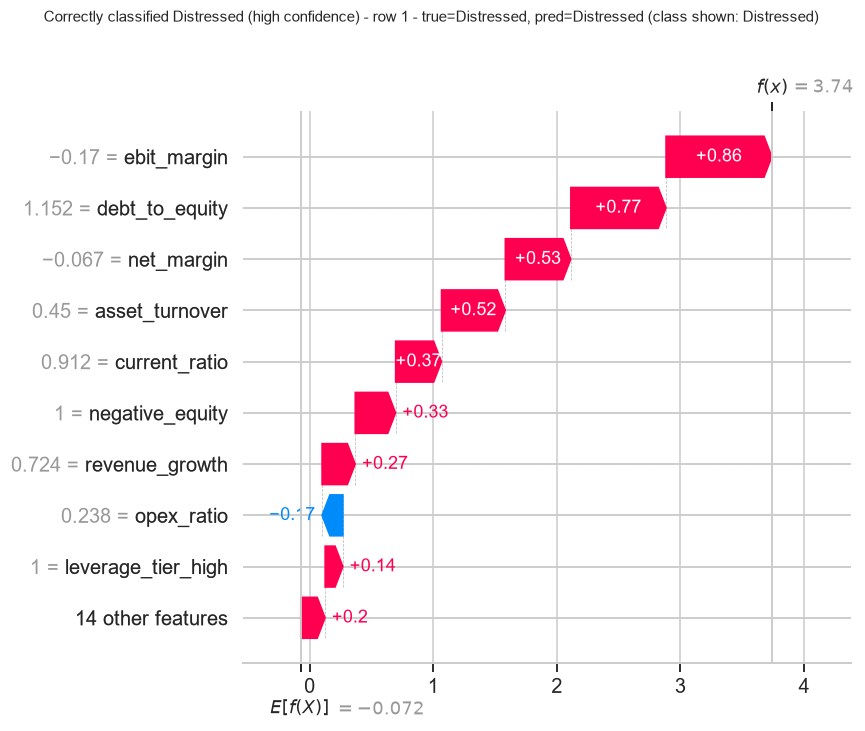

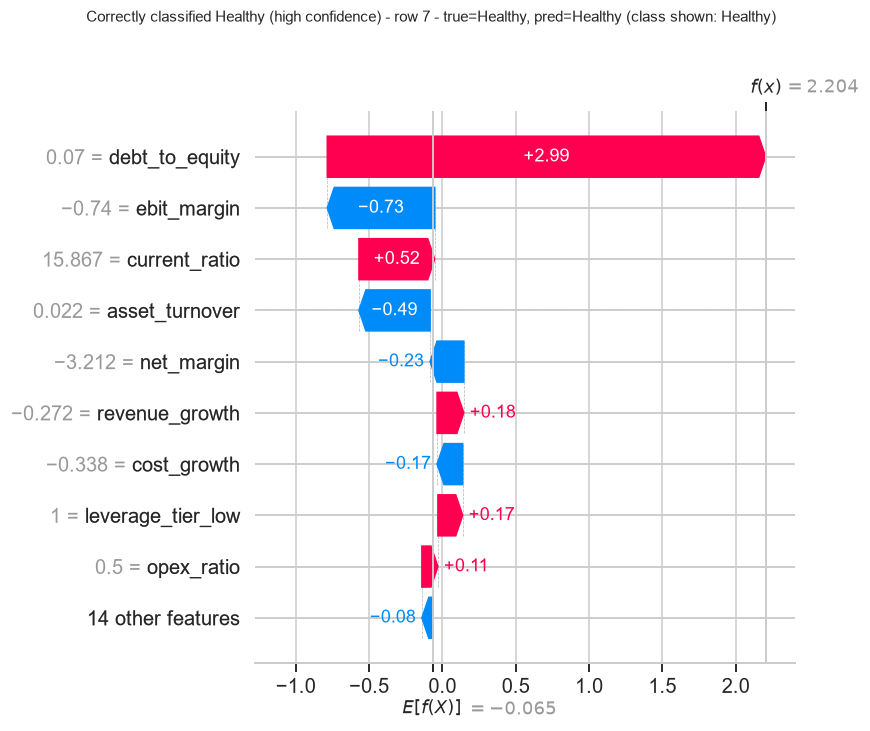

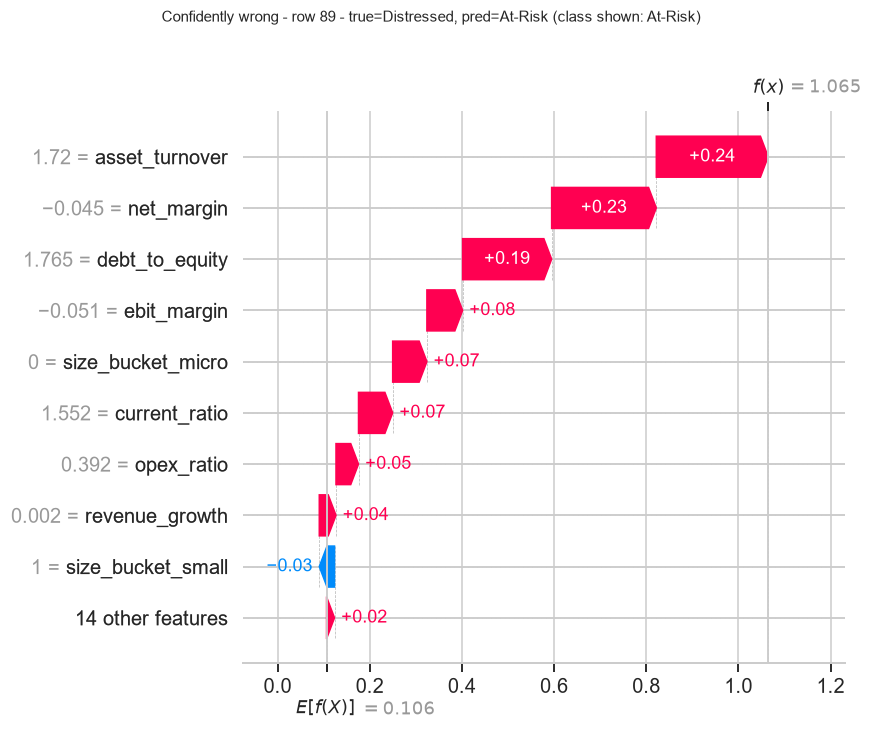

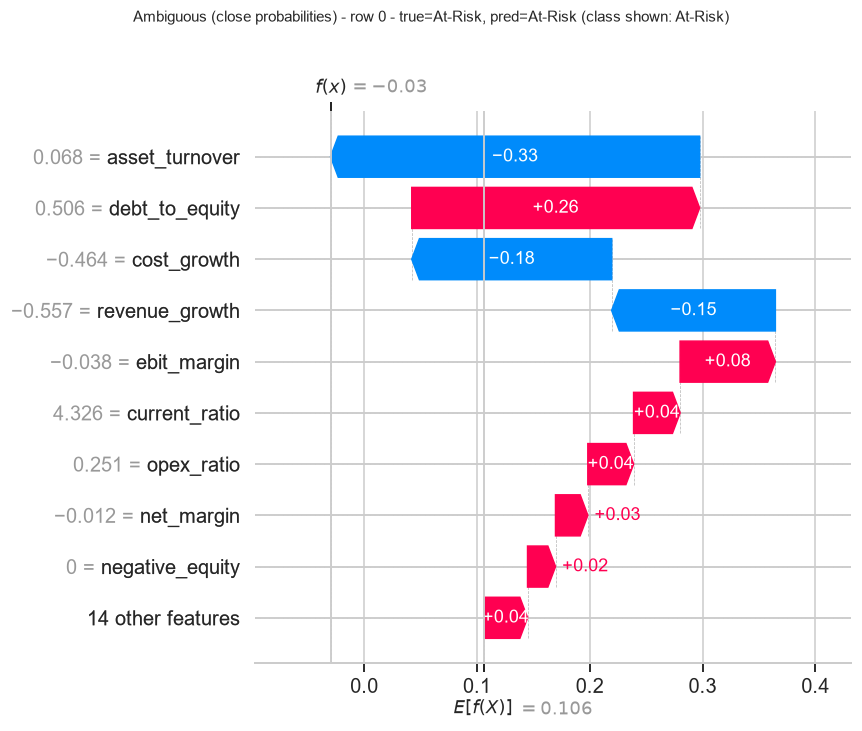

In [24]:
def waterfall_for_row(row_idx, case_label):
    """Waterfall plot for one company, showing top features pushing toward the predicted class."""
    pred_cls = int(np.argmax(proba[row_idx]))
    exp = shap.Explanation(
        values        = shap_values[row_idx, :, pred_cls],
        base_values   = float(explainer.expected_value[pred_cls]),
        data          = X.iloc[row_idx].values,
        feature_names = feature_cols,
    )
    fig = plt.figure()
    shap.plots.waterfall(exp, max_display=10, show=False)
    title = (f'{case_label} - row {row_idx} - '
             f'true={y_true_lbl[row_idx]}, pred={y_pred_lbl[row_idx]} '
             f'(class shown: {classes[pred_cls]})')
    plt.suptitle(title, fontsize=10, y=1.02)
    plt.tight_layout()
    safe = case_label.split(' ')[0].lower()
    fig.savefig(PLOTS_DIR / f'03_waterfall_{safe}_row{row_idx}.png', bbox_inches='tight')
    plt.show()

for label, idx in cases.items():
    if idx is not None:
        waterfall_for_row(idx, label)

## Step 8 - Also Run SHAP on the Logistic Baseline

In [25]:
try:
    logistic = load_model('logistic')
    # LinearExplainer needs the underlying sklearn model and a background sample
    background = shap.sample(X, 100, random_state=42)
    linear_exp = shap.LinearExplainer(logistic.model, logistic.scaler.transform(background))

    # Explain a sample of the test set for speed
    sample_X = X.sample(n=500, random_state=42)
    shap_lin = np.asarray(linear_exp.shap_values(logistic.scaler.transform(sample_X)))
    if shap_lin.ndim == 2:                       # binary-style output
        shap_lin = shap_lin[..., None]

    lin_mean_abs = np.abs(shap_lin).mean(axis=0).mean(axis=-1)
    lin_importance = pd.Series(lin_mean_abs, index=feature_cols).sort_values(ascending=False)

    print('Top 10 features - Logistic baseline (for comparison):')
    print(lin_importance.head(10).round(4))
    np.save(SHAP_DIR / 'shap_values_logistic.npy', shap_lin)
except Exception as e:
    print(f'Skipped logistic SHAP: {e}')

Top 10 features - Logistic baseline (for comparison):
asset_turnover              0.9688
leverage_tier_low           0.5633
current_ratio               0.4380
leverage_tier_high          0.3884
profit_regime_profitable    0.3733
profit_regime_loss          0.3592
size_bucket_micro           0.2266
opex_ratio                  0.1660
leverage_tier_med           0.1364
size_bucket_large           0.1356
dtype: float64


## Step 9 - Feature-Level Comparison: XGBoost vs Logistic

Spearman rank correlation between XGBoost and Logistic importance: rho = 0.357   (p = 0.0948)


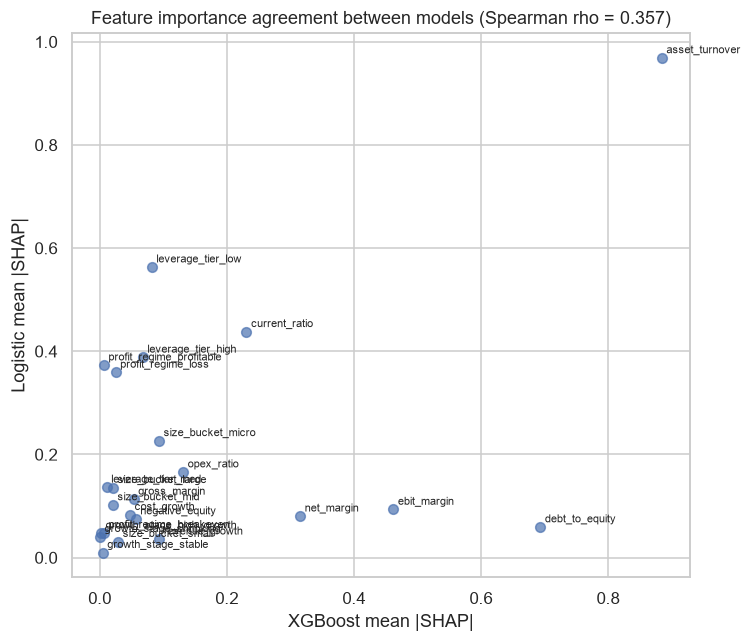

In [26]:
try:
    compare = pd.DataFrame({
        'XGBoost':  importance_df['Overall'].values,
    }, index=importance_df.index)
    compare = compare.join(lin_importance.rename('Logistic'), how='left').fillna(0)

    # Spearman rank correlation on feature importance
    from scipy.stats import spearmanr
    rho, pval = spearmanr(compare['XGBoost'], compare['Logistic'])
    print(f'Spearman rank correlation between XGBoost and Logistic importance: '
          f'rho = {rho:.3f}   (p = {pval:.4f})')

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(compare['XGBoost'], compare['Logistic'], s=40, alpha=0.7)
    for feat in compare.index:
        ax.annotate(feat, (compare.loc[feat, 'XGBoost'], compare.loc[feat, 'Logistic']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('XGBoost mean |SHAP|')
    ax.set_ylabel('Logistic mean |SHAP|')
    ax.set_title(f'Feature importance agreement between models (Spearman rho = {rho:.3f})')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '04_importance_agreement.png', bbox_inches='tight')
    plt.show()
except NameError:
    print('Logistic SHAP not available, skipping comparison plot.')

## Step 10 - Confident-Errors Deep Dive

In [27]:
try:
    errors = pd.read_csv(C.RESULTS_DIR / 'confident_errors.csv')
    print(f'Confident errors on file: {len(errors)}')

    # Join with SHAP summary so each error carries its explanation
    keys = ['company_id']
    if 'year' in errors.columns and 'year' in shap_summary.columns:
        keys.append('year')
    joined = errors.merge(shap_summary, on=keys, suffixes=('_err', ''))

    show_cols = ['company_id', 'year', 'label', 'pred_XGBoost', 'conf_XGBoost',
                 'top1_feature', 'top1_shap', 'top2_feature', 'top2_shap',
                 'top3_feature', 'top3_shap']
    show_cols = [c for c in show_cols if c in joined.columns]
    print(joined[show_cols].head(10).to_string(index=False))

    joined.to_csv(SHAP_DIR / 'shap_confident_errors.csv', index=False)
    print(f'\nSaved: {SHAP_DIR}/shap_confident_errors.csv')
except FileNotFoundError:
    print('confident_errors.csv not found - Member 2 has not committed it yet.')

Confident errors on file: 10
company_id  year      label pred_XGBoost  conf_XGBoost   top1_feature  top1_shap   top2_feature  top2_shap      top3_feature  top3_shap
      FTEK  2022    At-Risk      Healthy        0.9865 debt_to_equity     2.9005  current_ratio     0.4700       ebit_margin    -0.3982
       UGI  2023    At-Risk   Distressed        0.9696 debt_to_equity     1.1868    ebit_margin     0.9385    asset_turnover     0.6523
       ZVO  2021    At-Risk   Distressed        0.9629 asset_turnover    -1.4371    ebit_margin     1.3077    debt_to_equity     0.8144
       XRX  2024    At-Risk   Distressed        0.9618 debt_to_equity     1.1422    ebit_margin     0.6793        net_margin     0.6521
     BRK-A  2022    At-Risk   Distressed        0.9585 asset_turnover     1.6184     net_margin     0.5374    debt_to_equity     0.4461
      FTEK  2023    At-Risk      Healthy        0.9546 debt_to_equity     2.6489    ebit_margin    -0.5017    asset_turnover    -0.4192
      MRAM  2023   

## Step 11 - Verification Summary

In [28]:
expected_files = [
    SHAP_DIR / 'shap_values_xgboost.npy',
    SHAP_DIR / 'expected_values_xgboost.npy',
    SHAP_DIR / 'shap_top_features_xgboost.csv',
]

print('Files produced:')
for f in expected_files:
    if f.exists():
        print(f'  OK  {f.relative_to(C.ROOT)}   ({f.stat().st_size:,} bytes)')
    else:
        print(f'  MISSING  {f.relative_to(C.ROOT)}')

plots_produced = sorted(PLOTS_DIR.glob('*.png'))
print(f'\nPlots produced ({len(plots_produced)}):')
for p in plots_produced:
    print(f'  {p.relative_to(C.ROOT)}   ({p.stat().st_size:,} bytes)')

Files produced:
  OK  results\shap\shap_values_xgboost.npy   (380,732 bytes)
  OK  results\shap\expected_values_xgboost.npy   (140 bytes)
  OK  results\shap\shap_top_features_xgboost.csv   (245,426 bytes)

Plots produced (9):
  results\figures\shap\01_mean_abs_shap_top15.png   (111,723 bytes)
  results\figures\shap\02_beeswarm_at_risk.png   (231,437 bytes)
  results\figures\shap\02_beeswarm_distressed.png   (251,998 bytes)
  results\figures\shap\02_beeswarm_healthy.png   (228,131 bytes)
  results\figures\shap\03_waterfall_ambiguous_row0.png   (122,201 bytes)
  results\figures\shap\03_waterfall_confidently_row89.png   (122,649 bytes)
  results\figures\shap\03_waterfall_correctly_row1.png   (115,590 bytes)
  results\figures\shap\03_waterfall_correctly_row7.png   (124,880 bytes)
  results\figures\shap\04_importance_agreement.png   (111,216 bytes)
